# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

In [38]:
DATA_PATH = '.'  # e.g., './data'
FILE_NAME = 'Dataset.csv'  # <-- update to the actual file, e.g., 'Metro_Interstate_Traffic_Volume.csv'
file_path = os.path.join(DATA_PATH, FILE_NAME)
assert os.path.exists(file_path), f"File not found: {file_path}. Please place the dataset and update FILE_NAME."

df = pd.read_csv(file_path)
print(df['class'])
df.head()

0        S
1        S
2        S
3        S
4        S
        ..
15031    B
15032    B
15033    B
15034    B
15035    B
Name: class, Length: 15036, dtype: object


C:\Users\olive\AppData\Local\Temp\ipykernel_17812\1505496886.py:6: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S


In [39]:

# Replace any remaining '?' with NaN then fill
df.replace('?', np.nan, inplace=True)
df.fillna(0, inplace=True)

# Force all feature columns to numeric
X = df.drop(columns=['class'])
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)



In [40]:
le = LabelEncoder()
y = df['class'].map({'B': 0, 'S': 1})
df['class'] = le.fit_transform(df['class'])

print(le.classes_)   # ['B', 'S']  → B=0, S=1
print(df['class'].value_counts())


['B' 'S']
class
0    9476
1    5560
Name: count, dtype: int64


In [52]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score # Evaluation metrics
# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


SVM Accuracy: 0.9780585106382979
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1896
           1       0.97      0.97      0.97      1112

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008

Random Forest Accuracy: 0.988031914893617
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1112

    accuracy                           0.99      3008
   macro avg       0.99      0.99      0.99      3008
weighted avg       0.99      0.99      0.99      3008



In [46]:
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers
def standard_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation= 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation= 'sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

standard_model = standard_model()
standard_history = standard_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

C:\Users\olive\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8989 - loss: 0.2510 - val_accuracy: 0.9678 - val_loss: 0.0939
Epoch 2/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9678 - loss: 0.1038 - val_accuracy: 0.9771 - val_loss: 0.0720
Epoch 3/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9743 - loss: 0.0827 - val_accuracy: 0.9787 - val_loss: 0.0621
Epoch 4/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0683 - val_accuracy: 0.9814 - val_loss: 0.0590
Epoch 5/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9820 - loss: 0.0629 - val_accuracy: 0.9837 - val_loss: 0.0554
Epoch 6/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9832 - loss: 0.0545 - val_accuracy: 0.9854 - val_loss: 0.0525
Epoch 7/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9849 - loss: 0.0527 - val_accuracy: 0.9847 - val_loss: 0.0522
Epoch 8/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9852 - loss: 0.0487 - val_accuracy: 0.

In [49]:

standard_y_pred_nn = (standard_model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, standard_y_pred_nn))
print(classification_report(y_test, standard_y_pred_nn))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Neural Network Accuracy: 0.9886968085106383
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1112

    accuracy                           0.99      3008
   macro avg       0.99      0.99      0.99      3008
weighted avg       0.99      0.99      0.99      3008



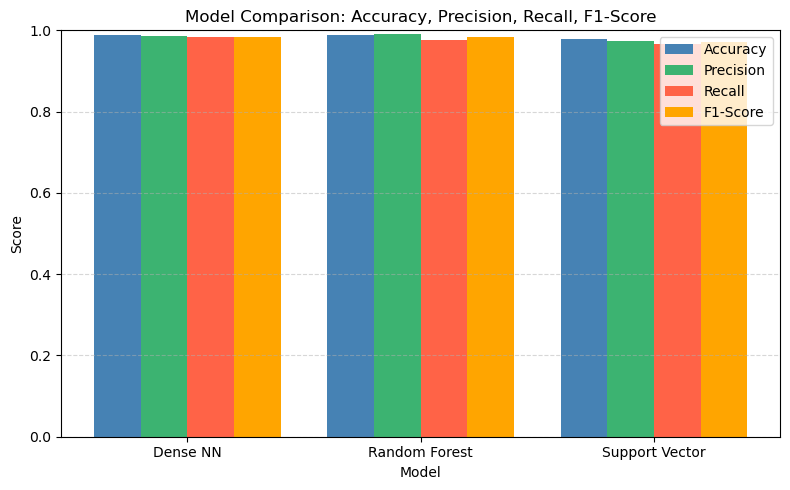

In [51]:

# Compute metrics for each model
models = ['Dense NN','Random Forest','Support Vector']
preds  = [standard_y_pred_nn,y_pred_rf, y_pred_svm]

accuracy  = [accuracy_score(y_test, p)               for p in preds]
precision = [precision_score(y_test, p, zero_division=0) for p in preds]
recall    = [recall_score(y_test, p, zero_division=0)    for p in preds]
f1        = [f1_score(y_test, p, zero_division=0)        for p in preds]

# Bar chart
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='steelblue')
ax.bar(x - 0.5*width, precision, width, label='Precision', color='mediumseagreen')
ax.bar(x + 0.5*width, recall,    width, label='Recall',    color='tomato')
ax.bar(x + 1.5*width, f1,        width, label='F1-Score',  color='orange')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy, Precision, Recall, F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
#
#
#
#
# Your code to develop AI model for malware classification.
# Hint: Use the example code provided in previous lab.
#
#
#
#

**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.